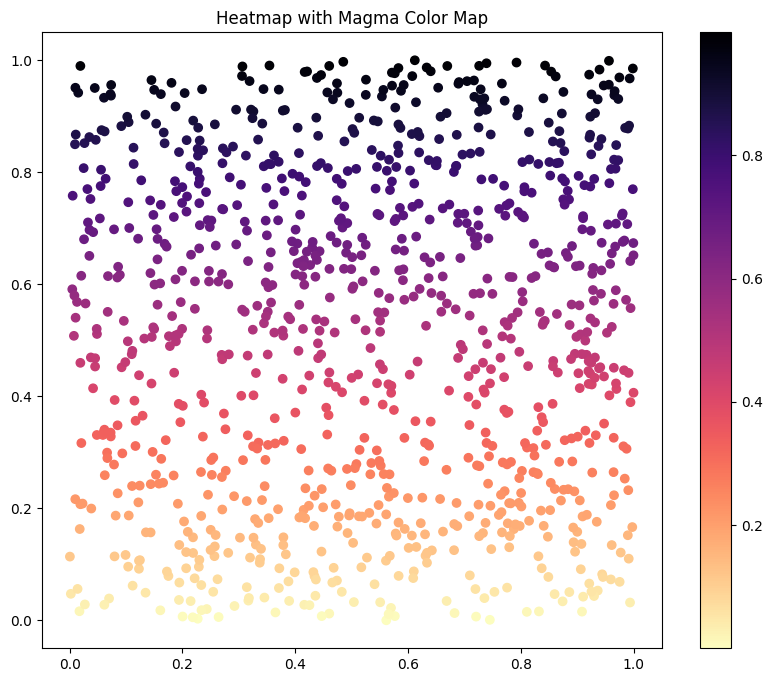

In [4]:
import numpy as np
import scanpy as sc
import os

import matplotlib.pyplot as plt

# Generate random data
data = np.random.rand(1000, 1200)

# Create the heatmap
plt.figure(figsize=(10, 8))
plt.scatter(data[:, 0], data[:, 1], c=data[:, 1], cmap='magma_r')
plt.colorbar()
plt.title('Heatmap with Magma Color Map')
plt.show()

In [2]:
adata = sc.read('./data/adata_mouse_brain_aging_MERFISH_imputed.h5ad')
adata

AnnData object with n_obs × n_vars = 378918 × 7308
    obs: 'fov', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'age', 'clust_annot', 'slice', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', '

In [3]:
adata.obsm['spatial'] = adata.obsm['spatial_coords']
del adata.obsm['spatial_coords']

In [5]:
for age in adata.obs['age'].unique():
    for donor_id in adata.obs['donor_id'].unique():
        donor_number = donor_id.split('_')[-1]
        for slice_ in adata.obs['slice'].unique():
            adata_sub = adata[(adata.obs['age'] == age) & (adata.obs['donor_id'] == donor_id) & (adata.obs['slice'] == slice_)]
            # print(age, donor_number, slice_, "cells:", adata_sub.n_obs)
            if adata_sub.n_obs > 0:
                data_path = f'./data/Mouse_brain_MERFISH_imputed/adata{age}_donor_id_{donor_number}_slice_{slice_}.h5ad'
                os.makedirs(os.path.dirname(data_path), exist_ok=True)
                adata_sub.write(data_path)
            del adata_sub

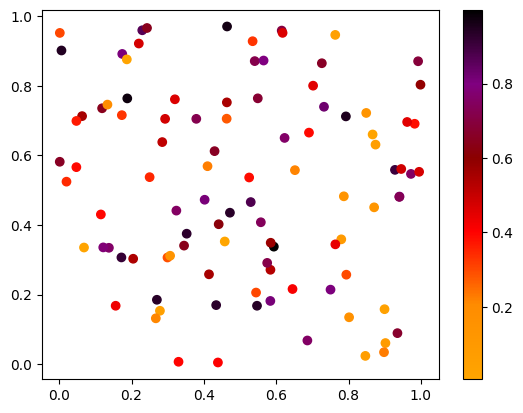

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Generate some data
x = np.random.rand(100)
y = np.random.rand(100)
colors = np.random.rand(100)

# Create a custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["orange", "darkorange", "red", "darkred", "purple", "black"])

# Plot the data with the custom colormap
plt.scatter(x, y, c=colors, cmap=cmap)
plt.colorbar()
plt.show()

In [ ]:
# import jensenshannon_divergence_backend from PASTE and try on the sample data


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [2]:
import locale
import inspect
import os
import sys
locale.getpreferredencoding = lambda: "UTF-8"

sys.path.append('MODIFIED_PYTHON_MODULES/modified_ot')
import ot

module_path = inspect.getfile(ot)
# Get the directory containing the module
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")

sys.path.append('MODIFIED_PYTHON_MODULES/modified_paste')
import paste as pst

module_path = inspect.getfile(pst)
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")

Module directory: /Users/anupbh/Home/thesis/incent-reproducibility/MODIFIED_PYTHON_MODULES/modified_ot/ot
Module directory: /Users/anupbh/Home/thesis/incent-reproducibility/MODIFIED_PYTHON_MODULES/modified_paste/paste


In [24]:
X = np.array([[2, 4]])
Y = np.array([[20, 40]])

In [27]:
pst.helper.jensenshannon_divergence_backend(X, Y)


Calculating cost matrix


100%|██████████| 1/1 [00:00<00:00, 2212.19it/s]

Finished calculating cost matrix


array([[0.]])

In [2]:
import numpy as np

In [3]:
pi_mat = np.load("local_data/incent/pi_matrix_adata4wk_donor_id_4_slice_1_adata24wk_donor_id_10_slice_1.npy")

In [4]:
row_sums = pi_mat.sum(axis=1)
print(row_sums)

[9.052231e-05 9.052231e-05 9.052231e-05 ... 9.052231e-05 9.052231e-05
 9.052231e-05]


In [5]:
print(pi_mat.shape)

(11047, 9617)


In [12]:
pi_mat = np.random.rand(10, 30).astype(np.float32)

In [13]:
def normalize_pi_matrix(matrix, max_iterations=1000, tolerance=1e-10):
    """
    Normalizes a matrix so that:
    - Each row sums to 1/num_rows
    - Each column sums to 1/num_cols
    
    Args:
        matrix: The input matrix to normalize
        max_iterations: Maximum number of iterations for convergence
        tolerance: Tolerance for checking convergence
        
    Returns:
        Normalized matrix
    """
    # Convert to numpy array if it's not already
    matrix = np.array(matrix, dtype=float)
    
    # Get dimensions
    m, n = matrix.shape
    row_target = 1.0 / m
    col_target = 1.0 / n
    
    # Make a copy to work with
    normalized = matrix.copy()
    
    for iteration in range(max_iterations):
        # Store the matrix before updates for convergence check
        prev_matrix = normalized.copy()
        
        # Step 1: Normalize rows to sum to 1/m
        row_sums = normalized.sum(axis=1, keepdims=True)
        # Avoid division by zero
        row_sums[row_sums == 0] = 1
        normalized = normalized * (row_target / row_sums)
        
        # Step 2: Normalize columns to sum to 1/n
        col_sums = normalized.sum(axis=0, keepdims=True)
        # Avoid division by zero
        col_sums[col_sums == 0] = 1
        normalized = normalized * (col_target / col_sums)
        
        # Check for convergence
        if np.max(np.abs(normalized - prev_matrix)) < tolerance:
            break
    
    return normalized

In [ ]:
normalized = normalize_pi_matrix(pi_mat)
    
print("\nNormalized matrix:")
print(normalized)

# Verify row sums
row_sums = normalized.sum(axis=1)
print("\nRow sums")
print(row_sums)

# Verify column sums
col_sums = normalized.sum(axis=0)
print("\nColumn sums")
print(col_sums)

pi_sum = np.sum(normalized)
print("\nSum of all elements in the normalized matrix:")
print(pi_sum)


In [ ]:
from sklearn.gaussian_process.kernels import RBF

rbf = RBF(length_scale=1.0)

source_coords = np.array([[0, 0], [1, 1], [2, 2]])
target_coords = np.array([[0, 0], [2, 1], [2, 2]])

# Evaluate the RBF kernel (similarity matrix)
rbf_matrix = rbf(source_coords, target_coords)


print(rbf_matrix)

[[1.         0.082085   0.01831564]
 [0.36787944 0.60653066 0.36787944]
 [0.01831564 0.60653066 1.        ]]


In [1]:
import numpy as np

def pairwise_msd(A, B):
    A = np.asarray(A)
    B = np.asarray(B)

    # A: (m, d), B: (n, d)
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]  # shape: (m, n, d)
    msd = np.mean(diff ** 2, axis=2)  # shape: (m, n)
    return msd


In [5]:
# make 2 matrices of different shapes, not random
A = np.array([[1, 2], [8, 4], [5, 6]])
B = np.array([[7, 4], [9, 10]])


print(pairwise_msd(A, B))


[[20.  64. ]
 [ 0.5 18.5]
 [ 4.  16. ]]


In [5]:
import scanpy as sc

In [50]:
adata = sc.read('./data/Mouse_brain_MERFISH/adata90wk_donor_id_3_slice_1.h5ad')
adata

AnnData object with n_obs × n_vars = 15844 × 374
    obs: 'fov', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'age', 'clust_annot', 'slice', 'organism_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_spatial_coords', 'X_umap', 'spatial'

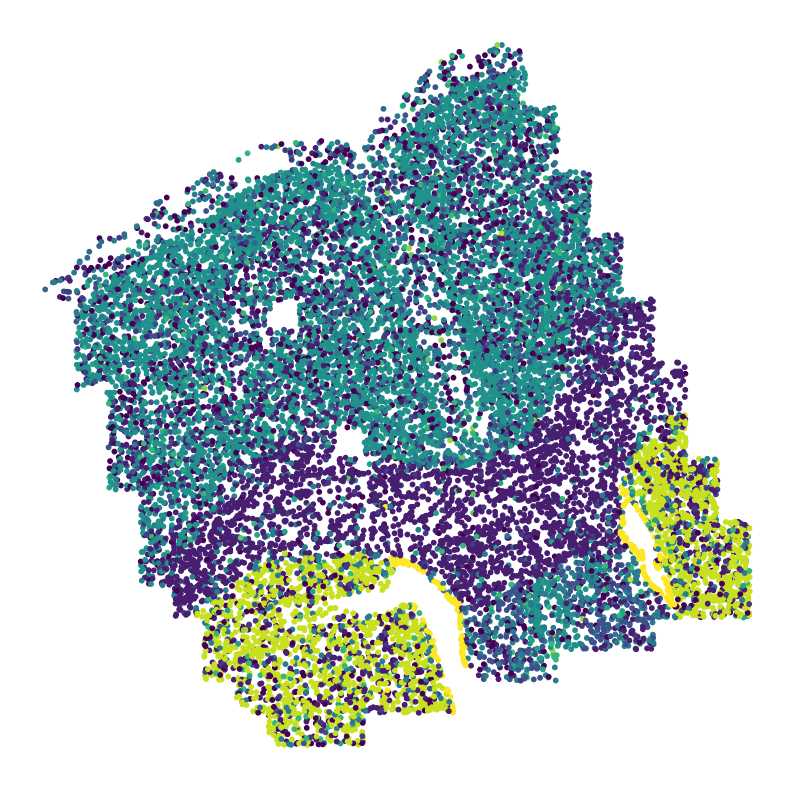

In [51]:
cell_type_color = {}
for i, cell_type in enumerate(adata.obs['cell_type'].unique()):
    cell_type_color[cell_type] = i
# cell_type_color['T cell'] = 'black'

plt.figure(figsize=(10, 10))
plt.axis('off')
plt.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], c=list(map(lambda x: cell_type_color[x], adata.obs['cell_type'])), s=10)

In [43]:
cell_type_color

{'neuron': 0,
 'endothelial cell': 1,
 'oligodendrocyte': 2,
 'oligodendrocyte precursor cell': 3,
 'inhibitory interneuron': 4,
 'microglial cell': 5,
 'astrocyte': 6,
 'macrophage': 7,
 'pericyte': 8,
 'medium spiny neuron': 9,
 'vascular leptomeningeal cell': 10,
 'T cell': 11,
 'cell': 12}